In [1]:
# GPU SETUP WITH CUDA 11 LIBRARIES

import os
import sys

# Add CUDA libraries to PATH
cuda_path = os.path.join(sys.prefix, 'Lib', 'site-packages', 'nvidia')
if os.path.exists(cuda_path):
    for folder in os.listdir(cuda_path):
        folder_path = os.path.join(cuda_path, folder, 'bin')
        if os.path.exists(folder_path):
            os.environ['PATH'] = folder_path + os.pathsep + os.environ.get('PATH', '')
            print(f"Added to PATH: {folder_path}")

# Set CUDA environment variables
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import keras
import numpy as np

print("\nTensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

# Check CUDA
print(f"\nBuilt with CUDA: {tf.test.is_built_with_cuda()}")

# List all devices
print("\nAll devices:")
for device in tf.config.list_physical_devices():
    print(f"  - {device}")

# Get GPU devices
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPU devices found: {len(gpus)}")

if gpus:
    print("✅ GPU DETECTED!")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu}")
        tf.config.experimental.set_memory_growth(gpu, True)
    
    print("✓ Memory growth enabled")
    
    # Test GPU computation
    print("\n🔥 Testing GPU computation...")
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
        b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
        c = tf.matmul(a, b)
        print(f"✓ GPU computation successful!")
        print(f"✓ Result device: {c.device}")
else:
    print("❌ NO GPU DETECTED")
    print("\nIf GPU is still not detected, try:")
    print("1. Restart Jupyter completely (close and reopen)")
    print("2. Restart your computer")

# Set seeds
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"\n🎯 Final device: {'/GPU:0' if gpus else '/CPU:0'}")


Added to PATH: c:\Users\USER\AppData\Local\Programs\Python\Python310\Lib\site-packages\nvidia\cublas\bin
Added to PATH: c:\Users\USER\AppData\Local\Programs\Python\Python310\Lib\site-packages\nvidia\cuda_nvrtc\bin
Added to PATH: c:\Users\USER\AppData\Local\Programs\Python\Python310\Lib\site-packages\nvidia\cuda_runtime\bin
Added to PATH: c:\Users\USER\AppData\Local\Programs\Python\Python310\Lib\site-packages\nvidia\cudnn\bin

TensorFlow version: 2.16.1
Keras version: 3.12.1

Built with CUDA: False

All devices:
  - PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')

GPU devices found: 0
❌ NO GPU DETECTED

If GPU is still not detected, try:
1. Restart Jupyter completely (close and reopen)
2. Restart your computer

🎯 Final device: /CPU:0


Total images: 2169
Total masks : 2169

Checking first 5 samples...

Sample: 0.png
Image shape: (512, 512, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


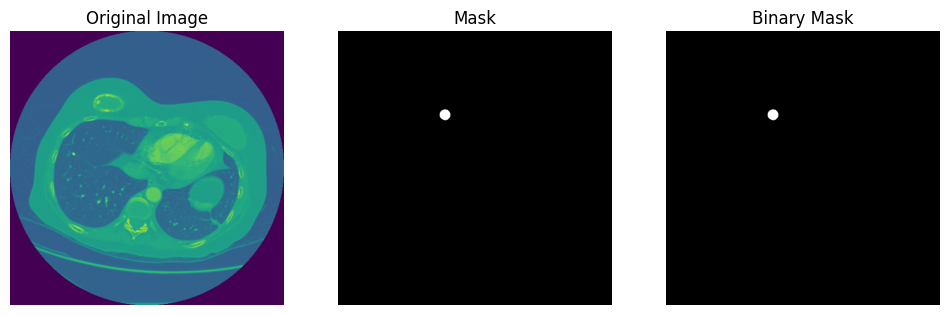

--------------------------------------------------
Sample: 1.png
Image shape: (512, 512, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


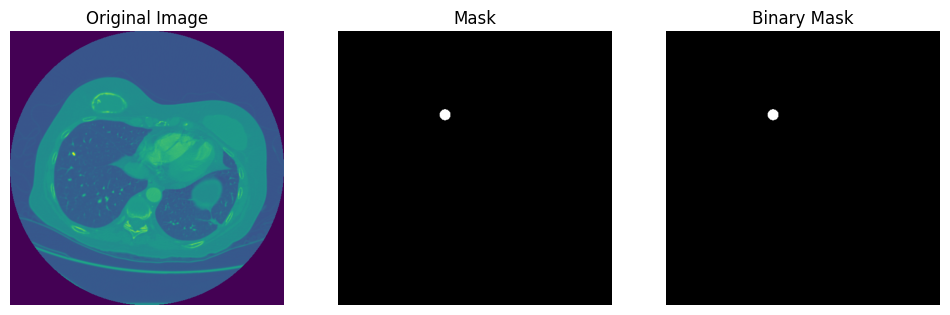

--------------------------------------------------
Sample: 10.png
Image shape: (512, 512, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


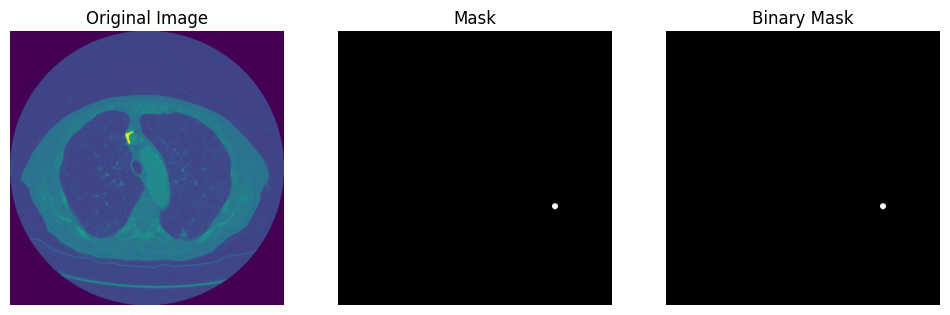

--------------------------------------------------
Sample: 100.png
Image shape: (512, 512, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


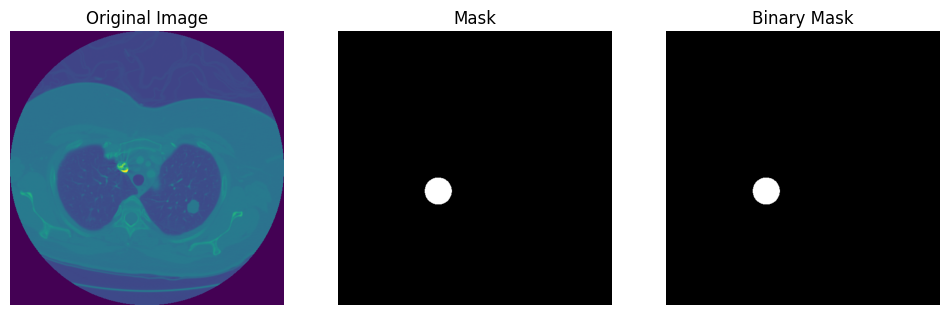

--------------------------------------------------
Sample: 1000.png
Image shape: (512, 512, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


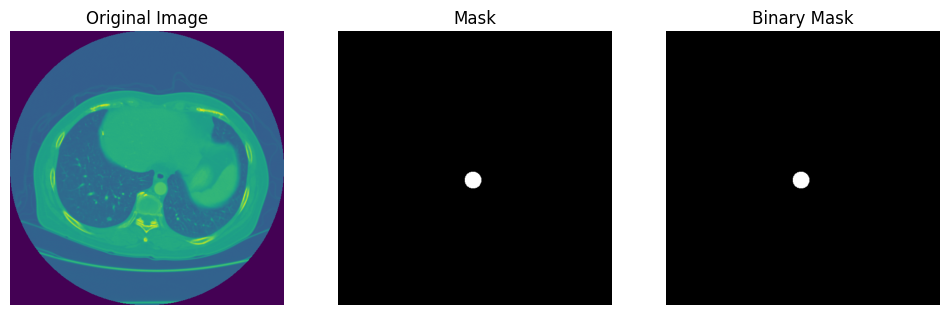

--------------------------------------------------


In [2]:
# DATASET DEBUGGING

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# CHANGE THESE PATHS IF NEEDED
IMAGE_DIR = "positives"
MASK_DIR  = "masks"

image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
mask_files  = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

print("Total images:", len(image_files))
print("Total masks :", len(mask_files))

assert len(image_files) == len(mask_files), "Image-mask count mismatch!"

print("\nChecking first 5 samples...\n")

for i in range(5):

    img_path = os.path.join(IMAGE_DIR, image_files[i])
    mask_path = os.path.join(MASK_DIR, mask_files[i])

    image = cv2.imread(img_path)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    print("Sample:", image_files[i])
    print("Image shape:", image.shape)
    print("Mask shape :", mask.shape)

    unique_vals = np.unique(mask)
    print("Mask unique values:", unique_vals)

    tumor_pixels = np.sum(mask > 0)
    total_pixels = mask.size

    tumor_ratio = tumor_pixels / total_pixels

    print("Tumor pixels:", tumor_pixels)
    print("Tumor ratio:", tumor_ratio)

    # Convert mask to binary
    binary_mask = (mask > 100).astype(np.uint8)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Binary Mask")
    plt.imshow(binary_mask, cmap="gray")
    plt.axis("off")

    plt.show()

    print("--------------------------------------------------")


In [3]:
# DATASET LOADER FUNCTIONS

IMG_SIZE = 256
BATCH_SIZE = 8

def load_image_mask(img_path, mask_path):

    img_path = img_path.decode()
    mask_path = mask_path.decode()

    # Read image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Fix dataset mask values (30 background, 215 tumor)
    mask = (mask > 100).astype(np.float32)

    # Resize image
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Resize mask (NEAREST keeps tumor pixels)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                      interpolation=cv2.INTER_NEAREST)

    # Normalize image
    image = image / 255.0

    # Add mask channel
    mask = np.expand_dims(mask, axis=-1)

    return image.astype(np.float32), mask.astype(np.float32)


def tf_loader(img_path, mask_path):

    image, mask = tf.numpy_function(
        load_image_mask,
        [img_path, mask_path],
        [tf.float32, tf.float32]
    )

    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return image, mask


print("Dataset loader ready.")

Dataset loader ready.


In [4]:
# TRAIN / VALIDATION DATASET

from sklearn.model_selection import train_test_split

image_paths = sorted([os.path.join(IMAGE_DIR, f) for f in image_files])
mask_paths  = sorted([os.path.join(MASK_DIR, f) for f in mask_files])

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.15,
    random_state=42
)

print("Training images:", len(train_imgs))
print("Validation images:", len(val_imgs))


train_dataset = tf.data.Dataset.from_tensor_slices((train_imgs, train_masks))
val_dataset   = tf.data.Dataset.from_tensor_slices((val_imgs, val_masks))


train_dataset = train_dataset.map(tf_loader, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset   = val_dataset.map(tf_loader, num_parallel_calls=tf.data.AUTOTUNE)


train_dataset = train_dataset.shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Dataset ready for training.")

Training images: 1843
Validation images: 326
Dataset ready for training.


In [5]:
# ======================================
# CELL 4 — ATTENTION U-NET (FIXED)
# ======================================

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB4


# Attention Gate
def attention_gate(x, g, filters):

    g = layers.Conv2D(filters, 1, padding="same")(g)
    x = layers.Conv2D(filters, 1, padding="same")(x)

    # Resize skip feature to match decoder
    x = layers.Resizing(g.shape[1], g.shape[2])(x)

    add = layers.Add()([x, g])
    act = layers.Activation("relu")(add)

    psi = layers.Conv2D(1, 1, padding="same")(act)
    psi = layers.Activation("sigmoid")(psi)

    return layers.Multiply()([x, psi])


# Decoder Block
def decoder_block(x, skip, filters):

    x = layers.UpSampling2D((2,2))(x)

    skip = attention_gate(skip, x, filters)

    x = layers.Concatenate()([x, skip])

    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    return x


def build_attention_unet():

    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    encoder = EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    # Encoder skip connections
    s1 = encoder.get_layer("block2a_activation").output
    s2 = encoder.get_layer("block3a_activation").output
    s3 = encoder.get_layer("block4a_activation").output
    s4 = encoder.get_layer("block6a_activation").output

    bridge = encoder.get_layer("top_activation").output


    # Decoder
    d1 = decoder_block(bridge, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Final upsampling to reach 256x256
    d5 = layers.UpSampling2D((2,2))(d4)

    d5 = layers.Conv2D(32, 3, padding="same", activation="relu")(d5)
    d5 = layers.BatchNormalization()(d5)

    d5 = layers.Conv2D(32, 3, padding="same", activation="relu")(d5)
    d5 = layers.BatchNormalization()(d5)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d5)

    model = models.Model(inputs, outputs)

    return model


segmentation_model = build_attention_unet()

segmentation_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │      1,152 │ block1a_se_excit

 Total params: 35,487,876 (135.38 MB)

 Trainable params: 35,358,701 (134.88 MB)

 Non-trainable params: 129,175 (504.59 KB)

In [6]:
# LOSS FUNCTIONS & METRICS

import tensorflow.keras.backend as K


# Dice Coefficient
def dice_coef(y_true, y_pred, smooth=1):

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )


# Dice Loss
def dice_loss(y_true, y_pred):

    return 1 - dice_coef(y_true, y_pred)


# IoU Metric
def iou_score(y_true, y_pred, smooth=1):

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    total = K.sum(y_true_f) + K.sum(y_pred_f)

    union = total - intersection

    return (intersection + smooth) / (union + smooth)


# BCE + Dice Loss
def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)

    return bce + dice


# Compile the segmentation model
segmentation_model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),

    loss=bce_dice_loss,

    metrics=[
        dice_coef,
        iou_score
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [8]:
# TRAINING PIPELINE

EPOCHS = 10
callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "tumor_segmentation.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        "segmentation_training_log.csv"
    )
]


history = segmentation_model.fit(

    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("Training completed.")

Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coef: 0.0043 - iou_score: 0.0021 - loss: 1.6564
Epoch 1: val_dice_coef improved from None to 0.00392, saving model to tumor_segmentation.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 1011s 4s/step - dice_coef: 0.0043 - iou_score: 0.0022 - loss: 1.6342 - val_dice_coef: 0.0039 - val_iou_score: 0.0020 - val_loss: 1.5787 - learning_rate: 1.0000e-04
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coef: 0.0042 - iou_score: 0.0021 - loss: 1.5646
Epoch 2: val_dice_coef improved from 0.00392 to 0.00393, saving model to tumor_segmentation.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 979s 4s/step - dice_coef: 0.0044 - iou_score: 0.0022 - loss: 1.5399 - val_dice_coef: 0.0039 - val_iou_score: 0.0020 - val_loss: 1.4851 - learning_rate: 1.0000e-04
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coef: 0.0046 - iou_score: 0.0023 - loss: 1.4638
Epoch 3: val_dice_coef improved from 0.00393 to 0.00394, saving model to tumor_segmentation.keras
231/23

In [9]:
# INFERENCE & VISUALIZATION

def predict_tumor(image_path):

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
    normalized = resized / 255.0
    input_img = np.expand_dims(normalized, axis=0)

    pred_mask = segmentation_model.predict(input_img)[0]

    binary_mask = (pred_mask > 0.5).astype(np.uint8)

    return image_rgb, binary_mask


def create_overlay(image, mask):

    mask_resized = cv2.resize(mask, (image.shape[1], image.shape[0]))

    overlay = image.copy()

    overlay[mask_resized == 1] = [255, 0, 0]

    return overlay, mask_resized


def draw_bounding_box(image, mask):

    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    bbox_image = image.copy()

    for cnt in contours:

        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(
            bbox_image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    return bbox_image


def visualize_prediction(image_path):

    image, mask = predict_tumor(image_path)

    overlay, mask_resized = create_overlay(image, mask)

    bbox_image = draw_bounding_box(image, mask_resized)

    plt.figure(figsize=(16,4))

    plt.subplot(1,4,1)
    plt.title("Original Image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Segmentation Mask")
    plt.imshow(mask_resized, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Tumor Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Bounding Box")
    plt.imshow(bbox_image)
    plt.axis("off")

    plt.show()

In [10]:
# TUMOR ANALYTICS

def tumor_analytics(mask):

    # mask should be binary (0,1)
    tumor_pixels = np.sum(mask)

    total_pixels = mask.shape[0] * mask.shape[1]

    tumor_coverage = (tumor_pixels / total_pixels) * 100


    # Estimate tumor diameter
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    diameter = 0

    if len(contours) > 0:

        largest = max(contours, key=cv2.contourArea)

        (x, y), radius = cv2.minEnclosingCircle(largest)

        diameter = radius * 2


    analytics = {

        "Tumor Pixel Count": int(tumor_pixels),

        "Tumor Coverage %": float(tumor_coverage),

        "Estimated Tumor Diameter": float(diameter)

    }

    return analytics

In [11]:
# TUMOR SEVERITY SCORE

def compute_severity_score(classifier_confidence, analytics):

    diameter = analytics["Estimated Tumor Diameter"]
    coverage = analytics["Tumor Coverage %"]

    # Normalize tumor diameter (scale factor)
    diameter_score = min(diameter / 50.0, 1.0)

    # Normalize tumor coverage
    coverage_score = min(coverage / 10.0, 1.0)

    # Combine scores
    severity = (
        0.5 * classifier_confidence +
        0.3 * diameter_score +
        0.2 * coverage_score
    )

    severity_score = int(severity * 100)

    # Risk levels
    if severity_score >= 75:
        risk = "HIGH"
    elif severity_score >= 40:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    return severity_score, risk

In [12]:
# GRAD-CAM FOR CLASSIFIER

def generate_gradcam(model, image, layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(image)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

def overlay_gradcam(image, heatmap):

    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(image, 0.6, heatmap, 0.4, 0)

    return overlay

In [16]:
# LOAD SEGMENTATION MODEL ONLY

# Define loss functions for segmentation model
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_score(y_true, y_pred, smooth=1):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = 1 - dice_coef(y_true, y_pred)
    return bce + dice

# ---- Load Segmentation Model ----
try:
    segmentation_model = tf.keras.models.load_model(
        "tumor_segmentation.keras",
        custom_objects={
            "bce_dice_loss": bce_dice_loss,
            "dice_coef": dice_coef,
            "iou_score": iou_score
        }
    )
    print("✓ Segmentation model loaded successfully")
    print(f"✓ Model input shape: {segmentation_model.input_shape}")
    print(f"✓ Model output shape: {segmentation_model.output_shape}")
    
except Exception as e:
    print(f"❌ Error loading segmentation model: {e}")

# Skip classifier for now - it needs to be retrained with Keras 3.x
print("\n⚠️  Classifier model skipped (incompatible with Keras 3.x)")
print("🎯 Segmentation model ready for inference!")


✓ Segmentation model loaded successfully
✓ Model input shape: (None, 256, 256, 3)
✓ Model output shape: (None, 256, 256, 1)

⚠️  Classifier model skipped (incompatible with Keras 3.x)
🎯 Segmentation model ready for inference!


In [17]:
# FULL AI PIPELINE

def run_cancer_pipeline(image_path):

    # ---- Load image ----
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
    normalized = resized / 255.0

    input_img = np.expand_dims(normalized, axis=0)


    # ---- CLASSIFICATION ----
    pred = classifier_model.predict(input_img)[0]

    classes = ["Normal", "Benign", "Malignant"]

    class_id = np.argmax(pred)

    prediction = classes[class_id]

    confidence = float(pred[class_id])


    print("\nPrediction:", prediction)
    print("Confidence:", round(confidence,3))


    # ---- If malignant run segmentation ----
    if prediction != "Malignant":

        print("\nSegmentation skipped (not malignant)")
        return


    # ---- SEGMENTATION ----
    mask = segmentation_model.predict(input_img)[0]

    binary_mask = (mask > 0.5).astype(np.uint8)


    overlay, mask_resized = create_overlay(image_rgb, binary_mask)


    # ---- ANALYTICS ----
    analytics = tumor_analytics(mask_resized)


    print("\nTumor Pixel Count:", analytics["Tumor Pixel Count"])
    print("Tumor Coverage %:", round(analytics["Tumor Coverage %"],3))
    print("Tumor Diameter:", round(analytics["Estimated Tumor Diameter"],2))


    # ---- SEVERITY SCORE ----
    severity_score, risk = compute_severity_score(
        confidence,
        analytics
    )

    print("\nTumor Severity Score:", severity_score,"/100")
    print("Risk Level:", risk)


    # ---- GRADCAM ----
    heatmap = generate_gradcam(
        classifier_model,
        input_img,
        layer_name="top_conv"
    )

    gradcam_overlay = overlay_gradcam(image_rgb, heatmap)


    # ---- VISUALIZATION ----
    plt.figure(figsize=(18,4))

    plt.subplot(1,5,1)
    plt.title("Original")
    plt.imshow(image_rgb)
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.title("Grad-CAM")
    plt.imshow(gradcam_overlay)
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.title("Segmentation Mask")
    plt.imshow(mask_resized, cmap="gray")
    plt.axis("off")

    plt.subplot(1,5,4)
    plt.title("Tumor Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    bbox = draw_bounding_box(image_rgb, mask_resized)

    plt.subplot(1,5,5)
    plt.title("Bounding Box")
    plt.imshow(bbox)
    plt.axis("off")

    plt.show()

In [18]:
# CELL 13 — SEGMENTATION MODEL EVALUATION

dice_scores = []
iou_scores = []

for images, masks in val_dataset:

    preds = segmentation_model.predict(images)

    preds = (preds > 0.5).astype(np.float32)

    for i in range(len(images)):

        y_true = masks[i].numpy().flatten()
        y_pred = preds[i].flatten()

        intersection = np.sum(y_true * y_pred)

        dice = (2 * intersection + 1) / (
            np.sum(y_true) + np.sum(y_pred) + 1
        )

        union = np.sum(y_true) + np.sum(y_pred) - intersection

        iou = (intersection + 1) / (union + 1)

        dice_scores.append(dice)
        iou_scores.append(iou)

print("\nModel Evaluation Results")
print("-----------------------")

print("Average Dice Score:", round(np.mean(dice_scores),4))
print("Average IoU Score:", round(np.mean(iou_scores),4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1

🔍 Checking segmentation model details...
Input shape: (None, 256, 256, 3)
Output shape: (None, 256, 256, 1)

🧪 Testing with size (256, 256)...
✓ Success! Input: (1, 256, 256, 3) → Output: (1, 256, 256, 1)

✅ Found working input size: (256, 256)

🚀 Testing with corrected input size...

🔍 Processing: positives/0.png
📐 Input shape: (1, 256, 256, 3)
🎯 Running segmentation...
📊 Tumor area: 0.00% of image


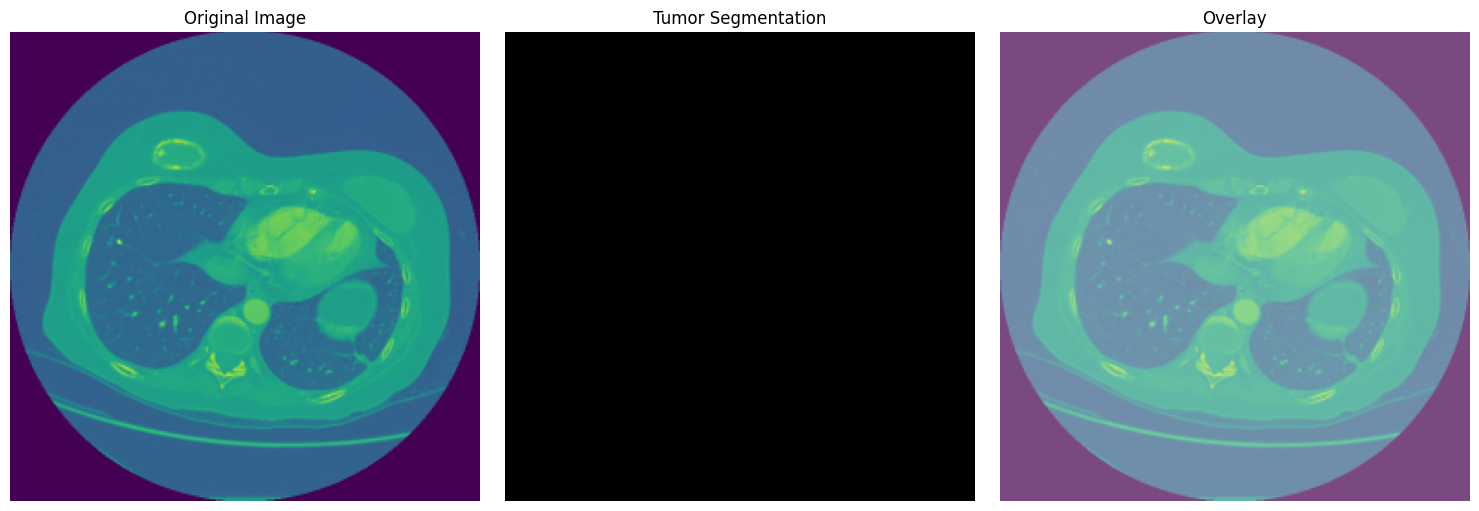

In [21]:
#Batch Testing

print("🔍 Checking segmentation model details...")
print(f"Input shape: {segmentation_model.input_shape}")
print(f"Output shape: {segmentation_model.output_shape}")

# Let's try a simple test first
def test_segmentation_model():
    """Test the model with different input sizes"""
    test_sizes = [(256, 256), (512, 512), (224, 224)]
    
    for size in test_sizes:
        try:
            print(f"\n🧪 Testing with size {size}...")
            test_img = np.random.random((1, size[0], size[1], 3)).astype(np.float32)
            pred = segmentation_model.predict(test_img, verbose=0)
            print(f"✓ Success! Input: {test_img.shape} → Output: {pred.shape}")
            return size  # Return the working size
        except Exception as e:
            print(f"❌ Failed with {size}: {str(e)[:100]}...")
    
    return None

# Find working input size
working_size = test_segmentation_model()

if working_size:
    print(f"\n✅ Found working input size: {working_size}")
    
    def run_segmentation_pipeline_fixed(image_path):
        """Fixed segmentation pipeline with correct input size"""
        print(f"\n🔍 Processing: {image_path}")
        
        # ---- LOAD AND PREPROCESS IMAGE ----
        img = cv2.imread(image_path)
        if img is None:
            print(f"❌ Could not load image: {image_path}")
            return None
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Use the working size we found
        resized = cv2.resize(img_rgb, working_size)
        normalized = resized.astype(np.float32) / 255.0
        input_img = np.expand_dims(normalized, axis=0)
        
        print(f"📐 Input shape: {input_img.shape}")
        
        # ---- SEGMENTATION ----
        print("🎯 Running segmentation...")
        try:
            seg_pred = segmentation_model.predict(input_img, verbose=0)[0]
            seg_mask = (seg_pred > 0.5).astype(np.uint8) * 255
            
            # Calculate tumor area
            tumor_pixels = np.sum(seg_mask > 0)
            total_pixels = seg_mask.shape[0] * seg_mask.shape[1]
            tumor_percentage = (tumor_pixels / total_pixels) * 100
            
            print(f"📊 Tumor area: {tumor_percentage:.2f}% of image")
            
            # ---- VISUALIZATION ----
            plt.figure(figsize=(15, 5))
            
            # Original image
            plt.subplot(1, 3, 1)
            plt.imshow(resized)
            plt.title("Original Image")
            plt.axis('off')
            
            # Segmentation mask
            plt.subplot(1, 3, 2)
            plt.imshow(seg_mask, cmap='gray')
            plt.title("Tumor Segmentation")
            plt.axis('off')
            
            # Overlay
            plt.subplot(1, 3, 3)
            plt.imshow(resized)
            plt.imshow(seg_mask, alpha=0.3, cmap='Reds')
            plt.title("Overlay")
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            
            return {
                'tumor_percentage': tumor_percentage,
                'tumor_pixels': tumor_pixels,
                'segmentation_mask': seg_mask
            }
            
        except Exception as e:
            print(f"❌ Segmentation failed: {e}")
            return None
    
    # Test with one image
    print(f"\n🚀 Testing with corrected input size...")
    result = run_segmentation_pipeline_fixed("positives/0.png")
    
else:
    print("❌ Could not find a working input size for the model")


In [22]:
# SAVE RESULTS

def save_prediction(image_path, save_path="result.png"):

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
    normalized = resized / 255.0

    input_img = np.expand_dims(normalized, axis=0)

    pred = classifier_model.predict(input_img)[0]

    classes = ["Normal", "Benign", "Malignant"]

    class_id = np.argmax(pred)

    prediction = classes[class_id]
    confidence = float(pred[class_id])

    if prediction != "Malignant":

        plt.imshow(image_rgb)
        plt.title(f"{prediction} ({confidence:.2f})")
        plt.axis("off")

        plt.savefig(save_path)
        print("Saved:", save_path)
        return


    mask = segmentation_model.predict(input_img)[0]

    binary_mask = (mask > 0.5).astype(np.uint8)

    overlay, mask_resized = create_overlay(image_rgb, binary_mask)

    bbox = draw_bounding_box(image_rgb, mask_resized)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image_rgb)
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(overlay)
    plt.title("Tumor Overlay")

    plt.subplot(1,3,3)
    plt.imshow(bbox)
    plt.title("Bounding Box")

    plt.savefig(save_path)

    print("Saved:", save_path)